In [11]:
import numpy as np
import pandas as pd
from torch import nn
from torchvision import transforms 
from torchvision import datasets 
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch
import cv2
from PIL import Image
import sklearn



In [12]:

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),

    ])  
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),      
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),     
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    
])

In [13]:
trainData = datasets.ImageFolder(root="../data/train", transform=train_transform)
train_loader = DataLoader(trainData, batch_size=32, shuffle=True)
testData = datasets.ImageFolder(root="../data/test", transform=test_transform)
test_loader = DataLoader(testData, batch_size=32, shuffle=False)


In [15]:
class ConvNeuralNet(nn.Module) : 
    def __init__(self, num_classes = 2):
        super(ConvNeuralNet, self).__init__() 
        self.convoLayer1 = nn.Conv2d(3,16,3,stride=1) 
        self.relu = nn.ReLU() 
        self.pool = nn.MaxPool2d(2,2)
        self.convoLayer2 = nn.Conv2d(16,32,3, stride=1)
        self.relu = nn.ReLU() 
        self.pool = nn.MaxPool2d(2,2)
        self.convoLayer3 = nn.Conv2d(32,64,3, stride=1)
        self.relu = nn.ReLU() 
        self.pool = nn.MaxPool2d(2,2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(43264, 512)
        self.output = nn.Linear(512, num_classes) 
        #lvaleur l theny hwa nbr de classes de sortie
    def forward(self, x): 
        out = self.convoLayer1(x)
        out = self.relu(out)
        out = self.pool(out)
        out = self.convoLayer2(out)
        out = self.relu(out)
        out = self.pool(out)
        out = self.convoLayer3(out)
        out = self.relu(out)
        out = self.pool(out)
        out = self.flatten(out)
        # out = out.view(out.size(0), -1)
        out = self.fc1(out)
        out = self.output(out)
        return out
    

torch.Size([32, 3, 224, 224])


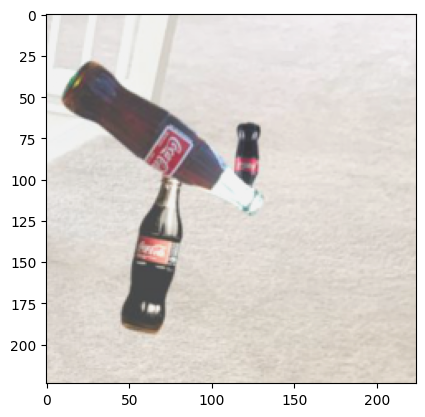

In [16]:
for images, labels in train_loader:
    print(images.shape)  
    img = images[1]
    plt.imshow(img.permute(1, 2, 0) * 0.5 + 0.5)
    plt.show()
    break  

In [6]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [17]:
model = ConvNeuralNet(num_classes=2) 
model = model.to(device) 
loss_fct = nn.CrossEntropyLoss() 
#optimoizer : bch naamlou update ll les poids mteena 3la 7asb taux d'erreur (loss function)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) 

In [8]:
print(torch.version.cuda)      # what version pytorch speaks


13.0


In [9]:
print(train_loader.dataset.classes)  # to know the classes of the dataset

['SodaBottle', 'WaterBottle']


In [18]:
for j in range (20) : #9adeh men mara kol image bch ysirlha training (passage par tous les couches)
    for i, (images, labels) in enumerate(train_loader): #images heya x li f modéle
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images) 
        loss = loss_fct(outputs, labels)
        optimizer.zero_grad() #bch naamlou reset ll les gradients mteena
        loss.backward() #bch naamlou calcul ll les gradients mteena
        optimizer.step() #bch naamlou update ll les poids mteena 3
        print('Epoch [{}/{}], Loss: {:.4f}'.format(j+1, 20, loss.item()))

Epoch [1/20], Loss: 0.6904
Epoch [1/20], Loss: 5.9675
Epoch [1/20], Loss: 0.8516
Epoch [1/20], Loss: 3.1314
Epoch [1/20], Loss: 1.2108
Epoch [1/20], Loss: 1.0620
Epoch [1/20], Loss: 1.1895
Epoch [1/20], Loss: 0.7164
Epoch [1/20], Loss: 0.5756
Epoch [1/20], Loss: 0.6843
Epoch [1/20], Loss: 0.6968
Epoch [1/20], Loss: 0.7767
Epoch [1/20], Loss: 0.7219
Epoch [1/20], Loss: 0.7430
Epoch [1/20], Loss: 0.6286
Epoch [1/20], Loss: 0.5682
Epoch [1/20], Loss: 0.7312
Epoch [1/20], Loss: 0.5285
Epoch [1/20], Loss: 0.4998
Epoch [1/20], Loss: 0.4824
Epoch [1/20], Loss: 0.6427
Epoch [1/20], Loss: 0.4896
Epoch [1/20], Loss: 0.4986
Epoch [1/20], Loss: 0.5805
Epoch [1/20], Loss: 0.4609
Epoch [1/20], Loss: 0.4386
Epoch [1/20], Loss: 0.4296
Epoch [1/20], Loss: 0.3388
Epoch [1/20], Loss: 0.4913
Epoch [1/20], Loss: 0.5874
Epoch [1/20], Loss: 0.3679
Epoch [1/20], Loss: 0.4190
Epoch [1/20], Loss: 0.2679
Epoch [1/20], Loss: 0.4109
Epoch [1/20], Loss: 0.5343
Epoch [1/20], Loss: 0.3033
Epoch [1/20], Loss: 0.4546
E

c:\Users\LENOVO\anaconda3\envs\DigitalEyes\lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/20], Loss: 0.1780
Epoch [1/20], Loss: 0.3104
Epoch [1/20], Loss: 0.1868
Epoch [1/20], Loss: 0.3559
Epoch [1/20], Loss: 0.2708
Epoch [1/20], Loss: 0.3524
Epoch [1/20], Loss: 0.0712
Epoch [1/20], Loss: 0.1372
Epoch [1/20], Loss: 0.3592
Epoch [1/20], Loss: 0.2263
Epoch [1/20], Loss: 0.1178
Epoch [1/20], Loss: 0.2137
Epoch [1/20], Loss: 0.5194
Epoch [1/20], Loss: 0.2057
Epoch [1/20], Loss: 0.2310
Epoch [1/20], Loss: 0.1237
Epoch [1/20], Loss: 0.5184
Epoch [1/20], Loss: 0.1855
Epoch [1/20], Loss: 0.2392
Epoch [1/20], Loss: 0.2889
Epoch [1/20], Loss: 0.2039
Epoch [1/20], Loss: 0.4143
Epoch [1/20], Loss: 0.3866
Epoch [1/20], Loss: 0.2217
Epoch [1/20], Loss: 0.2575
Epoch [1/20], Loss: 0.2498
Epoch [1/20], Loss: 0.3784
Epoch [1/20], Loss: 0.2313
Epoch [1/20], Loss: 0.1293
Epoch [1/20], Loss: 0.4638
Epoch [1/20], Loss: 0.1823
Epoch [1/20], Loss: 0.1027
Epoch [1/20], Loss: 1.5332
Epoch [1/20], Loss: 0.5122
Epoch [1/20], Loss: 0.2669
Epoch [1/20], Loss: 0.2433
Epoch [1/20], Loss: 0.1558
E

Testing

In [19]:
with torch.no_grad(): #n7absou l training
    correct = 0
    total = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) #torch.max : bch naamlou calcul ll les predictions mteena , 1 maaneha chercher dans les colonnes
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(total) 
    print(correct)
    accuracy = 100 * correct / total
    print(f'Accuracy: {accuracy:.2f}%')

6976
6833
Accuracy: 97.95%


In [20]:
with torch.no_grad(): #n7absou l training
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) 
        total += labels.size(0) 
        correct += (predicted == labels).sum().item() 
    print(total)
    print(correct)
    accuracy = 100 * correct / total
    print(f'Accuracy: {accuracy:.2f}%')

3448
3151
Accuracy: 91.39%


In [21]:
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix

with torch.no_grad():
    all_predictions = []
    all_labels = []
    
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    recall = recall_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions)

    print(f'Recall: {recall:.4f}')
    print(f'Precision: {precision:.4f}')


Recall: 0.8967
Precision: 0.9091


In [22]:
torch.save(model.state_dict(), 'model.pt')

In [23]:
myCNN = ConvNeuralNet(num_classes=2)

In [ ]:
# myCNN.load_state_dict(torch.load('model.pth'))
# myCNN.to(device)
# #charger les poids du modéle d'aprés fichier 'model.pth'

: 

: 

: 

: 

: 

In [ ]:
myCNN.eval()

ConvNeuralNet(
  (convoLayer1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (convoLayer2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (convoLayer3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=43264, out_features=512, bias=True)
  (output): Linear(in_features=512, out_features=2, bias=True)
)

: 

: 

: 

: 

: 

In [ ]:



import torch.nn.functional as F

# Now run the webcam
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    image = Image.fromarray(image)
    image = train_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():  # ✅ indented inside the while loop
        outputs = myCNN(image)
        probabilities = F.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

        predicted_label = trainData.classes[predicted.item()]

    cv2.putText(frame, predicted_label, (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    
    cv2.imshow("Digital Eyes", frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
    print(outputs)


cap.release()
cv2.destroyAllWindows()

RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

: 

: 

: 

: 

: 

In [ ]:
trainData.classes
trainData.class_to_idx



{'SodaBottle': 0, 'WaterBottle': 1}

: 

: 

: 

: 

: 

In [ ]:
image_path = "C:\\Users\\LENOVO\\Digital-Eyes\\CNNmodel\\fan.jpg"

def load_image(image_path):
    image = Image.open(image_path).convert('RGB')

    image = test_transform(image)
    return image.unsqueeze(0)  # Ajouter une dimension pour le batch

: 

: 

: 

: 

: 

In [ ]:
import torchvision

image = load_image(image_path)
image = image.to(device)

myCNN.eval()

with torch.no_grad():
    outputs = myCNN(image)
    _, predicted = torch.max(outputs, 1)
    predicted_label = trainData.classes[predicted.item()]
    

print(predicted_label)
outputs


SodaBottle


tensor([[ 7.6791, -7.6794]], device='cuda:0')

: 

: 

: 

: 

: 

In [ ]:
 # raka7 l quality of images urtout f soda folder ++ erjaa l e5er disc maa claude

: 

: 

: 

: 

: 

In [ ]:
testData.class_to_idx


{'SodaBottle': 0, 'WaterBottle': 1}

: 

: 

: 

: 

: 

In [ ]:
import cv2

: 

: 

: 

: 

: 

In [ ]:
# naamlou l hajet li similar kima milk juice // soda water // remote control phone // reading glasses sunglasses // 

: 

: 

: 

: 

: 